# PCA and KMeans Analysis

## Task 1

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

iris = load_iris()
X = iris.data
y = iris.target

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:")
print("PC1:", round(pca.explained_variance_ratio_[0], 4))
print("PC2:", round(pca.explained_variance_ratio_[1], 4))

Explained Variance Ratio:
PC1: 0.7296
PC2: 0.2285


## Task 2

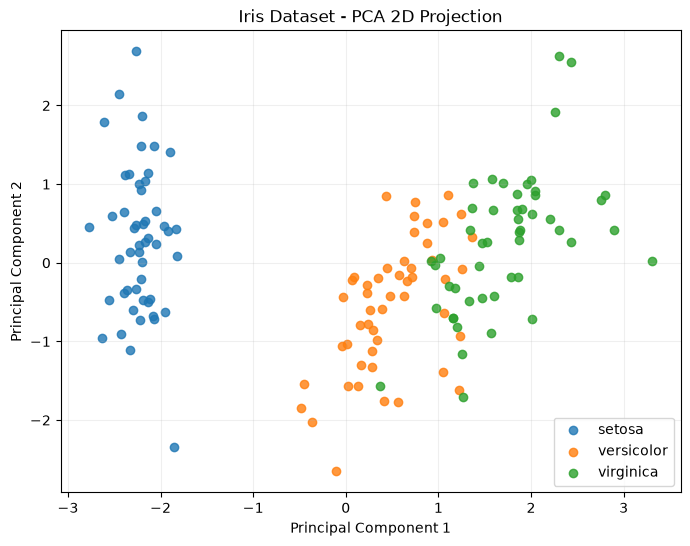

In [31]:
species = iris.target_names

plt.figure(figsize=(8, 6))
for i, name in enumerate(species):
    mask = y == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=name, alpha=0.8)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Iris Dataset - PCA 2D Projection")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Task 3

Explained Variance Ratio:
[0.148  0.1329 0.1195]
Cumulative Explained Variance:
[0.148  0.281  0.4004]


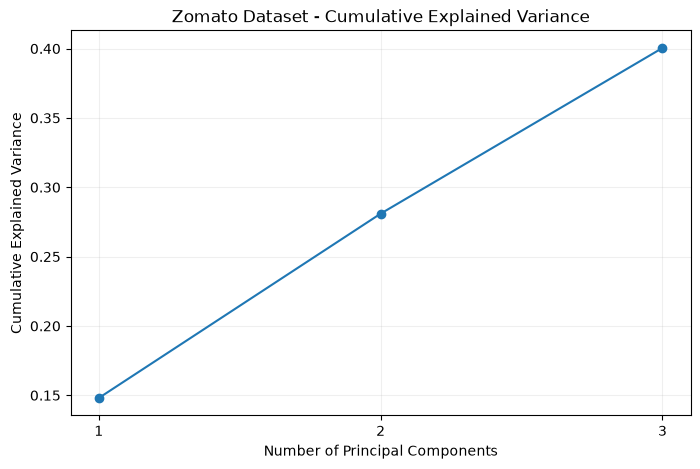

In [47]:
rng = np.random.default_rng(42)
zomato_data = rng.normal(size=(150, 10))

pca_zomato = PCA(n_components=3)
zomato_pca = pca_zomato.fit_transform(zomato_data)
cumulative_variance = np.cumsum(pca_zomato.explained_variance_ratio_)

print("Explained Variance Ratio:")
print(np.round(pca_zomato.explained_variance_ratio_, 4))
print("Cumulative Explained Variance:")
print(np.round(cumulative_variance, 4))

plt.figure(figsize=(8, 5))
plt.plot(range(1, 4), cumulative_variance, marker="o")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Zomato Dataset - Cumulative Explained Variance")
plt.xticks([1, 2, 3])
plt.grid(alpha=0.2)
plt.show()

## Task 4

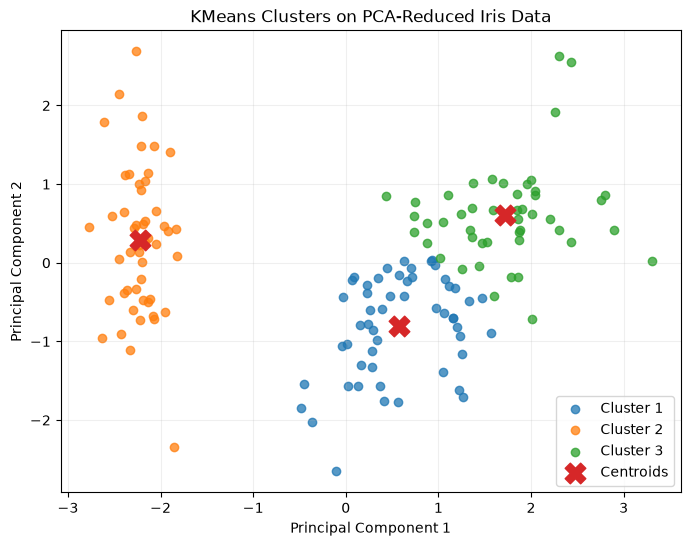

Centroids:
[[ 0.5726 -0.8072]
 [-2.2248  0.2889]
 [ 1.721   0.6029]]


In [56]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)
centroids = kmeans.cluster_centers_

plt.figure(figsize=(8, 6))
for cluster in range(3):
    mask = clusters == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f"Cluster {cluster + 1}", alpha=0.75)

plt.scatter(centroids[:, 0], centroids[:, 1], marker="X", s=220, label="Centroids")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("KMeans Clusters on PCA-Reduced Iris Data")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print("Centroids:")
print(np.round(centroids, 4))

## Task 5

In [65]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_pca, clusters)

print("Silhouette Score:", round(score, 10))

Silhouette Score: 0.5091683342
